# 3. Conformance Checking
## Invoice-to-Payment Process Optimization — BPI Challenge 2019
*See the [README](../README.md) for full project overview, business problem, and dataset details.*

This notebook directly addresses the **third part of the
[BPI Challenge 2019](https://icpmconference.org/2019/icpm-2019/contests-challenges/bpi-challenge-2019/)'s
three official questions**. The analysis' focus lies on Conformance
Checking and answers the following questions:

- Which Purchase Documents stand out from the log?
- Where are deviations from the processes discovered (see Process
  Discovery, Notebook 2) and how severe are these? — including also a
  deeper analysis of sub-populations (SRM cases, high-multiplicity cases)
- Which vendors* produce a lot of rework as invoices are wrong, etc.?

The challenge text also notes that deviations may concern invoice values,
not just process flow — this is examined separately (Section 3.6.4),
where feasibility of a literal invoice-vs-goods-receipt value check is
assessed.

*Note:* the original challenge text uses "customers" here, but given the
company is the buyer in this procurement process, this refers to vendors
— external suppliers submitting invoices — not the company's own
customers.

## 3.1 Imports & Setup
- Import libraries (pandas, pm4py)
- Mount Google Drive
- Load the cleaned dataset (BPI_2019_cleaned.parquet from Notebook 1)
- Reload/recreate the PM4Py-formatted log (as in Notebook 2, Section 2.2)

In [86]:
# Install dependencies
!pip install pm4py --quiet

In [87]:
# Imports
import pandas as pd
import pm4py

In [88]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [89]:
# Load the cleaned dataset from Notebook 1
file_path = "/content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/BPI Challenge 2019_Data/BPI_2019_cleaned.parquet"

event_log = pd.read_parquet(file_path)
print(f"Shape: {event_log.shape}")
event_log.head()

Shape: (1595603, 22)


,User,org:resource,concept:name,Cumulative net worth (EUR),time:timestamp,case:Spend area text,case:Company,case:Document Type,case:Sub spend area text,case:Purchasing Document,...,case:Item Type,case:Item Category,case:Spend classification text,case:Source,case:Name,case:GR-Based Inv. Verif.,case:Item,case:concept:name,case:Goods Receipt,event_month
0,batch_00,batch_00,SRM: Created,298.00,2018-01-02 12:53:00+00:00,CAPEX & SOCS,companyID_0000,EC Purchase order,Facility Management,2000000000,...,Standard,"3-way match, invoice before GR",NPR,sourceSystemID_0000,vendor_0000,False,00001,2000000000_00001,True,2018-01
1,batch_00,batch_00,SRM: Complete,298.00,2018-01-02 13:53:00+00:00,CAPEX & SOCS,companyID_0000,EC Purchase order,Facility Management,2000000000,...,Standard,"3-way match, invoice before GR",NPR,sourceSystemID_0000,vendor_0000,False,00001,2000000000_00001,True,2018-01
2,batch_00,batch_00,SRM: Awaiting Approval,298.00,2018-01-02 13:53:00+00:00,CAPEX & SOCS,companyID_0000,EC Purchase order,Facility Management,2000000000,...,Standard,"3-way match, invoice before GR",NPR,sourceSystemID_0000,vendor_0000,False,00001,2000000000_00001,True,2018-01
3,batch_00,batch_00,SRM: Document Completed,298.00,2018-01-02 13:53:00+00:00,CAPEX & SOCS,companyID_0000,EC Purchase order,Facility Management,2000000000,...,Standard,"3-way match, invoice before GR",NPR,sourceSystemID_0000,vendor_0000,False,00001,2000000000_00001,True,2018-01
4,batch_00,batch_00,SRM: In Transfer to Execution Syst.,298.00,2018-01-02 13:53:00+00:00,CAPEX & SOCS,companyID_0000,EC Purchase order,Facility Management,2000000000,...,Standard,"3-way match, invoice before GR",NPR,sourceSystemID_0000,vendor_0000,False,00001,2000000000_00001,True,2018-01


In [90]:
# Preserve event_month before pm4py's formatting step potentially alters it
event_month_backup = event_log['event_month'].copy()

event_log_formatted = pm4py.format_dataframe(
    event_log,
    case_id='case:concept:name',
    activity_key='concept:name',
    timestamp_key='time:timestamp'
)

event_log_formatted['event_month'] = event_month_backup

print(event_log_formatted.shape)

(1595603, 24)


## 3.2 De Facto Model — Conformance Against Discovered Behavior
- Discover a de facto reference model (dominant/mainstream behavior),
  e.g. via Inductive Miner with a frequency threshold
- Run conformance checking (token-based replay or alignments) on the full
  log against this de facto model
- Summarize fitness scores and identify rare/outlier variants

In [91]:
main_flow = event_log_formatted[event_log_formatted['case:Item Category'] == '3-way match, invoice before GR']

# Discover the de facto model — this becomes the reference for conformance checking

process_tree_de_facto = pm4py.discover_process_tree_inductive(main_flow)
net_de_facto, im_de_facto, fm_de_facto = pm4py.convert_to_petri_net(process_tree_de_facto)

In [92]:
# Token-based replay checks each trace against the discovered Petri net,
# simulating tokens flowing through the model to measure how well the
# actual case behavior matches the expected process structure

conformance_results = pm4py.conformance_diagnostics_token_based_replay(
    main_flow, net_de_facto, im_de_facto, fm_de_facto
)

print(f"Number of cases checked: {len(conformance_results)}")
print(f"Example result: {conformance_results[0]}")

replaying log with TBR, completed traces ::   0%|          | 0/7835 [00:00<?, ?it/s]

Number of cases checked: 221010
Example result: {'trace_is_fit': True, 'trace_fitness': 1.0, 'activated_transitions': [(tau_1, None), (tauSplit_5, None), (skip_9, None), (tauSplit_11, None), (init_loop_14, None), (d5c4007e-9084-405c-b330-9940cf5c99ec, 'SRM: Created'), (skip_18, None), (init_loop_19, None), (20fe3ead-64c5-4888-9fee-d081df936bfd, 'SRM: Complete'), (80c50a8c-bcb7-44de-b61f-55bc2c381171, 'SRM: Awaiting Approval'), (58d803d0-ac42-4c82-b7b7-d05d68cd7675, 'SRM: Document Completed'), (tauSplit_23, None), (tauSplit_32, None), (init_loop_35, None), (ac7dea80-2d81-4fdf-b63c-e0cef5637c33, 'SRM: In Transfer to Execution Syst.'), (tauSplit_41, None), (ccd130cc-5752-4ef4-9187-3ac4ca10608e, 'SRM: Ordered'), (13b9d3e0-359a-4217-accd-9c39b6afe145, 'SRM: Change was Transmitted'), (d270c98c-2616-4abe-9bc6-3e2de17ae201, 'Create Purchase Order Item'), (tauJoin_42, None), (41a264ae-b6fb-47f6-b256-f7ecce0794ac, 'Vendor creates invoice'), (skip_38, None), (tauJoin_33, None), (skip_25, None), (

In [93]:
# Re-discover with noise filtering, so rare/deviant behavior is NOT
# absorbed into the model — necessary for conformance checking to be
# meaningful (default noise_threshold=0.0 guarantees ~100% fitness,
# which defeats the purpose of detecting deviations)

process_tree_de_facto = pm4py.discover_process_tree_inductive(main_flow, noise_threshold=0.2)
net_de_facto, im_de_facto, fm_de_facto = pm4py.convert_to_petri_net(process_tree_de_facto)

conformance_results = pm4py.conformance_diagnostics_token_based_replay(
    main_flow, net_de_facto, im_de_facto, fm_de_facto
)

fitness_scores = [r['trace_fitness'] for r in conformance_results]
print(f"Number of cases checked: {len(conformance_results)}")
print(f"Average fitness: {sum(fitness_scores)/len(fitness_scores):.4f}")
print(f"Perfectly fit cases (fitness = 1.0): {sum(1 for f in fitness_scores if f == 1.0)}")
print(f"Imperfectly fit cases (fitness < 1.0): {sum(1 for f in fitness_scores if f < 1.0)}")

replaying log with TBR, completed traces ::   0%|          | 0/7835 [00:00<?, ?it/s]

Number of cases checked: 221010
Average fitness: 0.9960
Perfectly fit cases (fitness = 1.0): 212524
Imperfectly fit cases (fitness < 1.0): 8486


*Note on methodology:* The `noise_threshold=0.2` value corresponds to ProM's
own default filtering threshold for the Inductive Miner ([Kourani, Park & van
der Aalst, 2026](https://doi.org/10.1007/s44311-026-00046-8)). The same paper
directly confirms the phenomenon verified above: across 17 real-life event
logs, all discovered models achieved perfect fitness when no filtering threshold was applied.

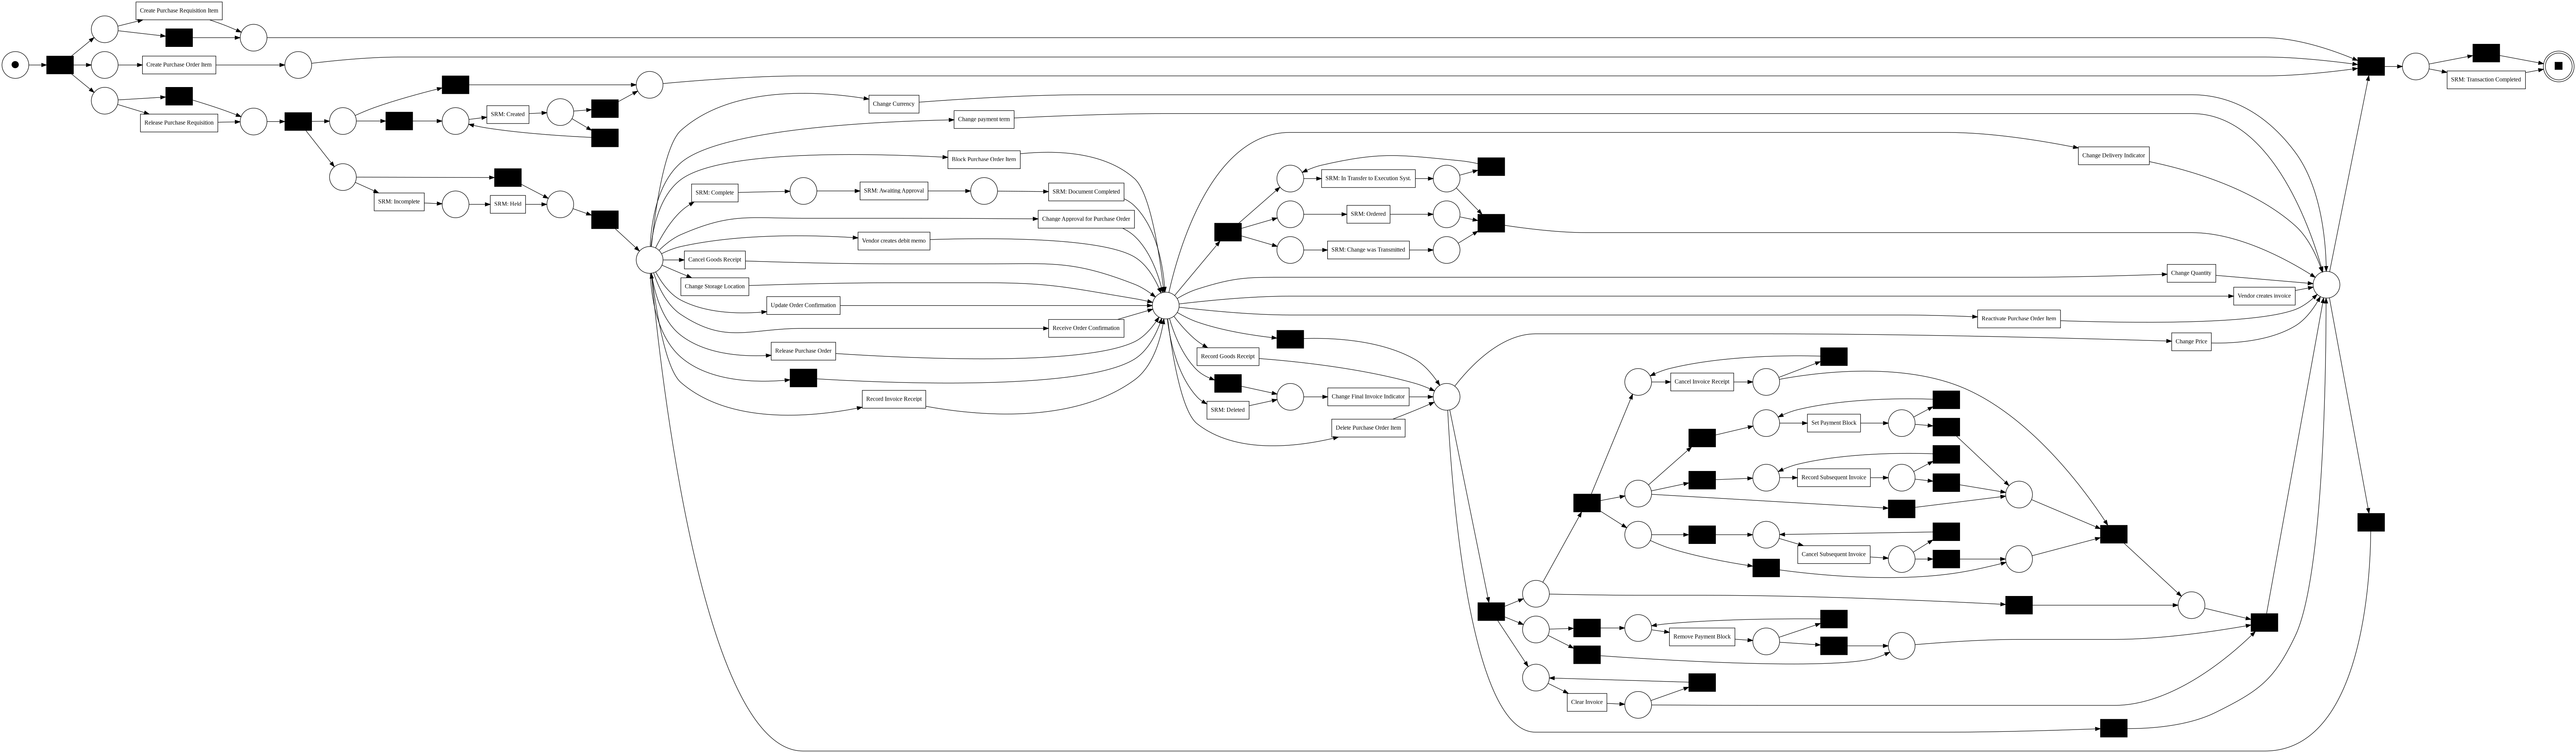

In [94]:
# Visualize the de facto model, for direct visual comparison with the
# de jure model built in Section 3.3
pm4py.view_petri_net(net_de_facto, im_de_facto, fm_de_facto)

In [95]:
# Save the de facto model

save_path_de_facto = "/content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/Images/de_facto_model.png"
pm4py.save_vis_petri_net(net_de_facto, im_de_facto, fm_de_facto, save_path_de_facto)
print(f"Saved to: {save_path_de_facto}")

Saved to: /content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/Images/de_facto_model.png


In [96]:
# Re-check: what does conformance look like against the ORIGINAL
# unfiltered model (noise_threshold=0.0, the default), to confirm
# whether it really does produce near-100% fitness as expected

process_tree_unfiltered = pm4py.discover_process_tree_inductive(main_flow, noise_threshold=0.0)
net_unfiltered, im_unfiltered, fm_unfiltered = pm4py.convert_to_petri_net(process_tree_unfiltered)

conformance_unfiltered = pm4py.conformance_diagnostics_token_based_replay(
    main_flow, net_unfiltered, im_unfiltered, fm_unfiltered
)

fitness_unfiltered = [r['trace_fitness'] for r in conformance_unfiltered]
print(f"Average fitness (unfiltered, noise_threshold=0.0): {sum(fitness_unfiltered)/len(fitness_unfiltered):.4f}")
print(f"Perfectly fit cases: {sum(1 for f in fitness_unfiltered if f == 1.0)} out of {len(fitness_unfiltered)}")

replaying log with TBR, completed traces ::   0%|          | 0/7835 [00:00<?, ?it/s]

Average fitness (unfiltered, noise_threshold=0.0): 0.9999
Perfectly fit cases: 220129 out of 221010


**Key insight — Filtering reveals meaningful deviations, unfiltered model
absorbs them:**

Conformance checking against the original (unfiltered) de
facto model shows near-perfect fitness (99.99% average fitness, 99.60% of
cases fitting exactly). This confirms that Inductive Miner without noise
filtering absorbs even rare behavior directly into the model, leading to
a very uninformative conformance check. Re-discovering with
`noise_threshold=0.2` produces a more selective model with a meaningfully
larger deviation signal: average fitness drops to 0.9960, and only 96.16%
of cases (212,524 of 221,010) fit exactly — 8,486 cases (3.84%) now show
genuine deviations from the mainstream, expected process behavior.

## 3.3 De Jure Model — Lightweight Reference Encoding
- Encode a simple de jure reference reflecting the four documented flow types
- Run conformance checking against this reference
- Compare results against the de facto model

*Note on methodology:* The BPI Challenge 2019 does not provide a formal, machine-readable reference (de jure) process model. Prior BPI Challenge 2019 submissions faced this same gap: [Augusto, Leno & Reissner (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Student-Submission-1.pdf) constructed as-is/to-be BPMN models but found them too complex for automated conformance techniques; [Diba, Remy & Pufahl (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Submission-6.pdf) (overall challenge winners) instead developed a rule-based compliance checking. Following this approach, this notebook constructs a lightweight de jure reference model directly from the challenge's documented flow-type description (Purchase Order → Goods Receipt → Invoice Receipt → Clear Invoice).

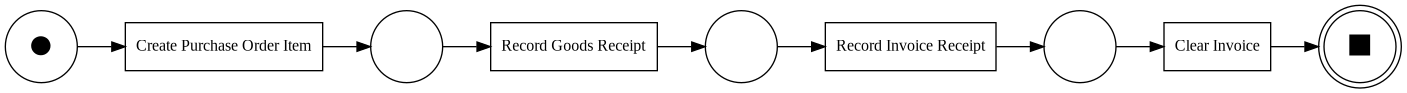

In [97]:
from pm4py.objects.petri_net.obj import PetriNet, Marking
from pm4py.objects.petri_net.utils import petri_utils

# Build a simple, lightweight de jure model reflecting the documented
# core sequence for "3-way match, invoice before GR"
de_jure_net = PetriNet("de_jure_3way_before_gr")

# Places
p_start = PetriNet.Place("p_start")
p1 = PetriNet.Place("p1")
p2 = PetriNet.Place("p2")
p3 = PetriNet.Place("p3")
p_end = PetriNet.Place("p_end")
de_jure_net.places.add(p_start)
de_jure_net.places.add(p1)
de_jure_net.places.add(p2)
de_jure_net.places.add(p3)
de_jure_net.places.add(p_end)

# Transitions (activities)
t1 = PetriNet.Transition("t1", "Create Purchase Order Item")
t2 = PetriNet.Transition("t2", "Record Goods Receipt")
t3 = PetriNet.Transition("t3", "Record Invoice Receipt")
t4 = PetriNet.Transition("t4", "Clear Invoice")
de_jure_net.transitions.add(t1)
de_jure_net.transitions.add(t2)
de_jure_net.transitions.add(t3)
de_jure_net.transitions.add(t4)

# Arcs connecting places and transitions in sequence
petri_utils.add_arc_from_to(p_start, t1, de_jure_net)
petri_utils.add_arc_from_to(t1, p1, de_jure_net)
petri_utils.add_arc_from_to(p1, t2, de_jure_net)
petri_utils.add_arc_from_to(t2, p2, de_jure_net)
petri_utils.add_arc_from_to(p2, t3, de_jure_net)
petri_utils.add_arc_from_to(t3, p3, de_jure_net)
petri_utils.add_arc_from_to(p3, t4, de_jure_net)
petri_utils.add_arc_from_to(t4, p_end, de_jure_net)

# Markings
im_de_jure = Marking()
im_de_jure[p_start] = 1
fm_de_jure = Marking()
fm_de_jure[p_end] = 1

pm4py.view_petri_net(de_jure_net, im_de_jure, fm_de_jure)

In [98]:
# Save the de jure model

save_path_de_jure = "/content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/Images/de_jure_model.png"
pm4py.save_vis_petri_net(de_jure_net, im_de_jure, fm_de_jure, save_path_de_jure)
print(f"Saved to: {save_path_de_jure}")

Saved to: /content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/Images/de_jure_model.png


In [99]:
# Conformance checking against this de jure model

conformance_de_jure = pm4py.conformance_diagnostics_token_based_replay(
    main_flow, de_jure_net, im_de_jure, fm_de_jure
)

fitness_de_jure = [r['trace_fitness'] for r in conformance_de_jure]
print(f"Number of cases checked: {len(conformance_de_jure)}")
print(f"Average fitness (de jure): {sum(fitness_de_jure)/len(fitness_de_jure):.4f}")
print(f"Perfectly fit cases: {sum(1 for f in fitness_de_jure if f == 1.0)} out of {len(fitness_de_jure)}")

replaying log with TBR, completed traces ::   0%|          | 0/7835 [00:00<?, ?it/s]

Number of cases checked: 221010
Average fitness (de jure): 0.9020
Perfectly fit cases: 147997 out of 221010


In [100]:
comparison_table = pd.DataFrame({
    'Model': ['De facto (unfiltered, noise_threshold=0.0)',
              'De facto (filtered, noise_threshold=0.2)',
              'De jure (documented policy)'],
    'Average fitness': [0.9999, 0.9960, 0.9020],
    'Perfectly fit cases': [220129, 212524, 147997],
    'Total cases': [221010, 221010, 221010]
})

comparison_table['% fitting'] = (comparison_table['Perfectly fit cases'] / comparison_table['Total cases'] * 100).round(2)

comparison_table

,Model,Average fitness,Perfectly fit cases,Total cases,% fitting
0,"De facto (unfiltered, noise_threshold=0.0)",1.00,220129,221010,99.60
1,"De facto (filtered, noise_threshold=0.2)",1.00,212524,221010,96.16
2,De jure (documented policy),0.90,147997,221010,66.96


**Key insight — De facto vs. de jure comparison:**

The results show that conformance decreases as the model becomes stricter and represents documented policy (de jure) instead of observed data (de facto).

- The **unfiltered de facto model** has a fitting rate of 99.60%, a nearly perfect match
- The **filtered de facto model** (noise_threshold=0.2) has a slightly lower fitting score of 96.16%
- The **de jure model** — comprising only the documented core sequence
(PO Item → GR → Invoice Receipt → Clear Invoice) — shows that just 66.96% of all cases fitting exactly, meaning 33.04% of cases deviating from the officially documented policy

This reveals a substantial gap between actual practice and official procedure
that a purely data-derived (de facto) analysis alone would understate, since
routine deviations become "normal" in a model discovered from the same data.

*Note on methodology:* "Perfectly fit cases" (%) counts only cases with
fitness = 1.0 exactly. "Average fitness" instead averages the continuous,
partial-credit fitness score across all cases — so a case with one minor
deviation still contributes a high (but not perfect) score, rather than
counting as a full failure. Example: given 100 cases, of which 67 fit
perfectly (fitness = 1.0) and 33 have one minor deviation each
(fitness ≈ 0.7), the perfect-fit rate is 67%, while average fitness =
(67 × 1.0 + 33 × 0.7) / 100 = (67 + 23.1) / 100 = 0.901.

## 3.4 Compliance Rule Check
- Encode the challenge's explicit compliance rule
- Check the log against this rule directly (rule-based, not model-based,
  consistent with Diba/Remy/Pufahl's approach for this same dataset)

In [101]:
# Reconstructed helper function for 3.4's compliance rule checks —
# implements both response rules ("A requires B after it") and precedence
# rules ("B requires A before it"), per Diba, Remy & Pufahl (2019)'s
# definitions
def check_response_rule(df, activity_a, activity_b, rule_type='response'):
    """
    Checks either a precedence rule ('B requires A before it') or a
    response rule ('A requires B after it') for a given event log.

    rule_type: 'precedence' or 'response'
    activity_a: the earlier activity in the expected order
    activity_b: the later activity in the expected order

    Returns: (violation_count, total_cases_checked, violation_percentage)
    """
    violations = 0
    cases_checked = 0

    for case_id, group in df.groupby('case:concept:name'):
        group_sorted = group.sort_values('time:timestamp')
        activities_in_order = group_sorted['concept:name'].tolist()

        if rule_type == 'response':
            if activity_a in activities_in_order:
                cases_checked += 1
                a_index = activities_in_order.index(activity_a)
                if activity_b not in activities_in_order[a_index + 1:]:
                    violations += 1

        elif rule_type == 'precedence':
            if activity_b in activities_in_order:
                cases_checked += 1
                b_index = activities_in_order.index(activity_b)
                if activity_a not in activities_in_order[:b_index]:
                    violations += 1

    pct = (violations / cases_checked * 100) if cases_checked > 0 else 0
    return violations, cases_checked, pct

In [102]:
violations, total, pct = check_response_rule(
    main_flow, 'Record Goods Receipt', 'Record Invoice Receipt'
)
print(f"Rule: Record Goods Receipt → Record Invoice Receipt (response)")
print(f"Violations: {violations} out of {total} cases with the trigger activity ({pct:.2f}%)")

Rule: Record Goods Receipt → Record Invoice Receipt (response)
Violations: 22595 out of 206474 cases with the trigger activity (10.94%)


In [103]:
# Check: are "violating" cases concentrated near the end of the
# observation period (2019), suggesting they are incomplete rather
# than genuinely non-compliant?

violating_case_ids = []
for case_id, group in main_flow.groupby('case:concept:name'):
    group_sorted = group.sort_values('time:timestamp')
    activities = group_sorted['concept:name'].tolist()
    if 'Record Goods Receipt' in activities:
        trigger_idx = activities.index('Record Goods Receipt')
        if 'Record Invoice Receipt' not in activities[trigger_idx + 1:]:
            violating_case_ids.append(case_id)

violating_last_events = main_flow[main_flow['case:concept:name'].isin(violating_case_ids)].groupby('case:concept:name')['time:timestamp'].max()
print(violating_last_events.dt.to_period('M').value_counts().sort_index().tail(10))

time:timestamp
2018-04    1139
2018-05    1665
2018-06    2272
2018-07    1828
2018-08    1928
2018-09    1501
2018-10    2065
2018-11    2152
2018-12    2158
2019-01    4183
Freq: M, Name: count, dtype: int64


/tmp/ipykernel_3616/2408268571.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  print(violating_last_events.dt.to_period('M').value_counts().sort_index().tail(10))


In [104]:
# How much of the total violation count is concentrated in the final months?

recent_violations = violating_last_events[violating_last_events >= '2018-10-01'].shape[0]
total_violations = len(violating_last_events)

print(f"Violations with last event in Oct 2018 - Jan 2019: {recent_violations}")
print(f"Total violations: {total_violations}")
print(f"Percentage: {recent_violations/total_violations*100:.1f}%")

Violations with last event in Oct 2018 - Jan 2019: 10558
Total violations: 22595
Percentage: 46.7%


**Key insight — Response rule violation (GR → Invoice Receipt):**

10.94% of cases (22,595 of 206,474) with a "Record Goods Receipt" show no subsequent
"Record Invoice Receipt" within the case. However, violating cases cluster
at the end of the observation window (10,558 of 22,595 cases with
violations, 46.7%); January 2019 alone accounts for 18.5% of violations,
nearly double the rate of other months. This suggests a substantial number
of cases are still in progress at the end of the observation period,
representing incomplete traces rather than genuine compliance failures.

*Note on methodology:* This pattern is called the "snapshots challenge" and
was identified by Wil van der Aalst as one of five key challenges in event
log extraction (cited in [Bernard & Andritsos, 2020](https://doi.org/10.1007/978-3-030-49418-6_10)), describing how an event log extraction that cuts traces at a fixed date can create truncated/incomplete traces that resemble genuine violations.

In [105]:
# Follow-up: check whether some "violations" are actually cases where
# Invoice Receipt genuinely occurred before Goods Receipt (a legitimate,
# independently-confirmed pattern for this category, see NB4 4.2.3 — 8.21%
# of cases) rather than incomplete/open cases
gr_time = main_flow[main_flow['concept:name'] == 'Record Goods Receipt'].groupby('case:concept:name')['time:timestamp'].first()
ir_time = main_flow[main_flow['concept:name'] == 'Record Invoice Receipt'].groupby('case:concept:name')['time:timestamp'].first()

cases_with_gr = set(gr_time.index)
cases_with_ir = set(ir_time.index)
common_cases = cases_with_gr & cases_with_ir
ir_before_gr = ir_time.loc[list(common_cases)] < gr_time.loc[list(common_cases)]
n_ir_before_gr = ir_before_gr.sum()

print(f"Cases with both GR and IR: {len(common_cases):,}")
print(f"Of those, IR's first occurrence is before GR's: {n_ir_before_gr:,}")

Cases with both GR and IR: 199,242
Of those, IR's first occurrence is before GR's: 16,356


In [106]:
# Cases with GR but NO IR event at all (genuinely incomplete, distinct from IR-before-GR)
cases_with_gr_no_ir = cases_with_gr - cases_with_ir
print(f"Cases with GR, no IR event at all: {len(cases_with_gr_no_ir):,}")
print(f"Cases with GR, IR occurred before GR: {n_ir_before_gr:,}")
print(f"Sum of both explanations: {len(cases_with_gr_no_ir) + n_ir_before_gr:,}")
print(f"Original violation count: 22,595")

Cases with GR, no IR event at all: 7,232
Cases with GR, IR occurred before GR: 16,356
Sum of both explanations: 23,588
Original violation count: 22,595


**Key insight — Response rule violation (GR → Invoice Receipt):**

10.94% of cases (22,595 of 206,474) with a "Record Goods Receipt" show no
subsequent "Record Invoice Receipt" within the case. A closer
investigation reveals this is driven by two distinct populations:

- 72.4% of violations (16,356 cases) are actually cases where **Invoice
  Receipt genuinely occurred *before* Goods Receipt** — a legitimate,
  already-documented business pattern for this category (matching NB4's
  independently-confirmed 8.21% finding almost exactly) rather than a
  compliance failure
- The remaining violations (7,232 cases, 32.0%) have **no IR event at
  all**, which is consistent with incomplete traces — the original,
  unrefined population (all 22,595 violations, not yet re-checked against
  just this subset) clusters at the end of the observation window (10,558
  cases, 46.7%, occurred late), with January 2019 alone accounting for
  18.5% of violations (4,183 of 22,595 — nearly double the rate of other
  months)

*Note on methodology:* The genuinely-incomplete subset is consistent with
the "snapshots challenge," identified by Wil van der Aalst as one of five
key challenges in event log extraction (cited in
[Bernard & Andritsos, 2020](https://doi.org/10.1007/978-3-030-49418-6_10)),
where a fixed-date extraction can create truncated/incomplete traces resembling
genuine violations. The late-clustering statistics
above were computed on the full, mixed 22,595-case population, not
re-verified against the 7,232-case no-IR-at-all subset specifically.

*Note on figures:* the two explanatory populations (16,356 + 7,232 =
23,588) sum to slightly more than the original violation count (22,595) —
a modest discrepancy (993 cases, ~4.4%) likely reflecting cases meeting
both conditions under slightly different check boundaries. This does not
change the overall conclusion that IR-before-GR is the dominant driver of
the observed violation rate.

In [107]:
# Reconstructed helper function — checks a response or precedence rule for
# a given pair of activities (needed by the compliance rule checks below)
def check_rule(df, rule_type, activity_a, activity_b):
    """Wrapper: checks a response or precedence rule (see check_response_rule)."""
    violations = 0
    cases_checked = 0
    for case_id, group in df.groupby('case:concept:name'):
        group_sorted = group.sort_values('time:timestamp')
        activities_in_order = group_sorted['concept:name'].tolist()
        if rule_type == 'response':
            if activity_a in activities_in_order:
                cases_checked += 1
                a_index = activities_in_order.index(activity_a)
                if activity_b not in activities_in_order[a_index + 1:]:
                    violations += 1
        elif rule_type == 'precedence':
            if activity_b in activities_in_order:
                cases_checked += 1
                b_index = activities_in_order.index(activity_b)
                if activity_a not in activities_in_order[:b_index]:
                    violations += 1
    pct = (violations / cases_checked * 100) if cases_checked > 0 else 0
    return violations, cases_checked, pct

In [108]:
# Check each consecutive link in the de jure sequence
rules_to_check = [
    ('response', 'Create Purchase Order Item', 'Record Goods Receipt'),
    ('response', 'Record Goods Receipt', 'Record Invoice Receipt'),  # already done
    ('response', 'Record Invoice Receipt', 'Clear Invoice'),
]

results = []
for rule_type, a, b in rules_to_check:
    violations, checked, pct = check_rule(main_flow, rule_type, a, b)
    results.append({'Rule': f'{a} → {b}', 'Type': rule_type,
                     'Violations': violations, 'Cases checked': checked,
                     '% violating': round(pct, 2)})

rules_df = pd.DataFrame(results)
rules_df

,Rule,Type,Violations,Cases checked,% violating
0,Create Purchase Order Item → Record Goods Receipt,response,14536,221010,6.58
1,Record Goods Receipt → Record Invoice Receipt,response,22595,206474,10.94
2,Record Invoice Receipt → Clear Invoice,response,26259,199564,13.16


*Note:* the "Record Goods Receipt → Record Invoice Receipt" row's 10.94%
figure includes both genuinely incomplete cases and a large share (72.4%
of this row's violations) of legitimate reverse-ordering cases — see the
detailed Key Insight above for the full breakdown. The other two rows
have not been investigated to the same depth and should be read as raw,
unrefined violation rates.

## 3.5 Segmented Conformance
- Repeat key conformance checks segmented by `case:Item Category`
  (the four flow types), consistent with the project's segmented
  analysis approach
- Compare conformance/compliance rates across segments

In [109]:
# Run the de jure sequence check across the THREE remaining categories
# (excluding "3-way match, invoice before GR", already checked in 3.4)
categories = event_log_formatted['case:Item Category'].unique()
remaining_categories = [c for c in categories if c != '3-way match, invoice before GR']
print(remaining_categories)

segment_results = []
for category in remaining_categories:
    segment = event_log_formatted[event_log_formatted['case:Item Category'] == category]
    for a, b in [('Create Purchase Order Item', 'Record Goods Receipt'),
                 ('Record Goods Receipt', 'Record Invoice Receipt'),
                 ('Record Invoice Receipt', 'Clear Invoice')]:
        violations, checked, pct = check_rule(segment, 'response', a, b)
        segment_results.append({'Category': category, 'Rule': f'{a} → {b}',
                                 'Violations': violations, 'Cases checked': checked,
                                 '% violating': round(pct, 2)})

segment_df = pd.DataFrame(segment_results)
segment_df

['3-way match, invoice after GR', 'Consignment', '2-way match']


,Category,Rule,Violations,Cases checked,% violating
0,"3-way match, invoice after GR",Create Purchase Order Item → Record Goods Receipt,644,15182,4.24
1,"3-way match, invoice after GR",Record Goods Receipt → Record Invoice Receipt,3411,14539,23.46
2,"3-way match, invoice after GR",Record Invoice Receipt → Clear Invoice,1456,11128,13.08
3,Consignment,Create Purchase Order Item → Record Goods Receipt,1032,14498,7.12
4,Consignment,Record Goods Receipt → Record Invoice Receipt,13466,13466,100.00
5,Consignment,Record Invoice Receipt → Clear Invoice,0,0,0.00
6,2-way match,Create Purchase Order Item → Record Goods Receipt,1044,1044,100.00
7,2-way match,Record Goods Receipt → Record Invoice Receipt,0,0,0.00
8,2-way match,Record Invoice Receipt → Clear Invoice,384,687,55.90


**Key insight — De jure model applicability:**

Applying the de jure model to the "3-way match, invoice after GR" flow type
reveals similar rule violation rates as for the other 3-way flow type. The
process violations change along the de jure sequence, but differ in scale
and pattern (4.24% → 23.46% → 13.08%).

Applying the single de jure model with a 3-way matching focus to the 2-way
match and Consignment flow types reveals its misfit:

- **Consignment cases** never contain "Record Invoice Receipt" events (0
  cases checked for "Invoice Receipt → Clear Invoice"), while "Record
  Goods Receipt → Record Invoice Receipt" shows 100% violation (13,466
  cases)
- **2-way match cases** never contain "Record Goods Receipt" events (0
  cases checked for "Record Goods Receipt → Record Invoice Receipt"),
  while "Create Purchase Order Item → Record Goods Receipt" shows 100%
  violation (1,044 cases)

This is not a compliance failure, but shows that each flow type requires
its own de jure reference. Comparable results are only useful for rules
with substantial case coverage:

- Consignment rule "Create Purchase Order Item → Record Goods Receipt":
  7.12% violation
- 2-way match rule "Invoice Receipt → Clear Invoice": 55.90% violation
- Others: systematically irrelevant

*Cross-validation:* This category-specific reasoning is confirmed by the
challenge's best student submission
([Meyer zu Wickern, Juluru, Roy, Vu & Nguyen, 2019](https://icpmconference.org/wp-content/uploads/BPI-Challenge-Student-Submission-4.pdf)),
who built identical category-based compliance logic — explicitly treating
Consignment items without invoices, and 2-way match items without goods
receipts, as **compliant rather than deviating**, since these categories
structurally do not require those steps. Additionally, an independent
study using the BPI 2019 challenge dataset
([Rebmann, Kampik, Corea & van der Aa, 2024](https://arxiv.org/pdf/2407.02336))
detected 15,182 traces after filtering to "3-way match, invoice after GR"
— an exact match to this notebook's own segmentation figures.

In [110]:
# Case-level category distribution — needed for the comparison table below
category_distribution = event_log_formatted.groupby('case:concept:name')['case:Item Category'].first().value_counts()
category_pct = (category_distribution / category_distribution.sum() * 100).round(2)

In [111]:
# Show the distribution of flow types, supporting the decision to focus
# de jure compliance checking on the two 3-way match categories

category_table = pd.DataFrame({
    'Cases': category_distribution,
    '% of total cases': category_pct
}).sort_values('% of total cases', ascending=False)

category_table['Cumulative %'] = category_table['% of total cases'].cumsum().round(2)

category_table

,Cases,% of total cases,Cumulative %
case:Item Category,,,
"3-way match, invoice before GR",221010,87.80,87.80
"3-way match, invoice after GR",15182,6.03,93.83
Consignment,14498,5.76,99.59
2-way match,1044,0.41,100.00


In [112]:
avg_events_per_case = event_log_formatted.groupby('case:Item Category').size() / category_distribution
print(avg_events_per_case)

case:Item Category
2-way match                       5.63
3-way match, invoice after GR    21.02
3-way match, invoice before GR    5.59
Consignment                       2.49
dtype: float64


**Key insight — De jure model scope:**

The de jure reference model was built for the 3-way matching structure
(see 3.4 and 3.5), which also dominates the number of total cases:

- **3-way match categories** together account for 93.83% of all cases
  ("invoice before GR": 87.80%, "invoice after GR": 6.03%); the de jure
  model applies meaningfully to these categories
- **2-way match** and **Consignment** combined represent 6.17% of all
  cases; furthermore, applying the reference model does not lead to
  meaningful results here, since these categories structurally lack the
  relevant activities — 2-way match cases never contain "Record Goods
  Receipt," and Consignment cases never contain "Record Invoice Receipt"

Because 3-way matching structures dominate and the de jure reference
model fits this business logic, this analysis focuses the de jure
compliance check on the two 3-way match categories.

*Note on case-level distribution:* The case-level distribution (87.80% /
6.03% / 5.76% / 0.41% for invoice-before-GR, invoice-after-GR,
Consignment, 2-way match respectively) differs from the event-level
distribution used elsewhere in this project (77.37% / 20.00% / 2.26% /
0.37%), because average case length varies substantially by category:
"invoice after GR" cases average 21 events each — roughly 4x longer than
"invoice before GR" or 2-way match (5.6 events each), and 8x longer than
Consignment (2.5 events each). This explains why "invoice after GR"
represents a much larger share of events than cases. For the purpose of
this compliance scoping decision, the relevant figure is the **case-level**
percentage: the two 3-way match categories together cover 93.83% of all
cases — still a strong majority, supporting the scoping decision.

## 3.6 Deviation Analysis

### 3.6.1 SRM cases and high-multiplicity cases
- Cross-reference deviating cases against known sub-populations from
  Notebooks 1-2

In [113]:
case_ids_ordered = main_flow['case:concept:name'].unique()
print(len(case_ids_ordered))

221010


In [114]:
# Verify the lengths match

print(len(conformance_results), len(case_ids_ordered))

221010 221010


In [115]:
# Count of deviating cases

fitness_by_case = pd.DataFrame({
    'case_id': case_ids_ordered,
    'fitness': fitness_scores
})

deviating_cases = fitness_by_case[fitness_by_case['fitness'] < 1.0]['case_id']
print(f"Number of deviating cases: {len(deviating_cases)}")

Number of deviating cases: 8486


In [116]:
# Redefine SRM case IDs (originally identified in Notebook 1/2)
# for use in this notebook's conformance analysis

srm_activities = [a for a in event_log_formatted['concept:name'].unique() if a.startswith('SRM')]
srm_case_ids = event_log_formatted[event_log_formatted['concept:name'].isin(srm_activities)]['case:concept:name'].unique()
srm_case_ids_set = set(srm_case_ids)

print(f"Number of SRM cases: {len(srm_case_ids_set)}")

Number of SRM cases: 1440


In [117]:
# Deviating overlap of SRM cases

deviating_srm_overlap = set(deviating_cases) & srm_case_ids_set
print(f"Deviating cases that are also SRM cases: {len(deviating_srm_overlap)}")
print(f"Out of {len(srm_case_ids_set)} total SRM cases")

Deviating cases that are also SRM cases: 43
Out of 1440 total SRM cases


In [118]:
# Define "high-multiplicity" cases as those in the top 5% by event count
# within this flow type — i.e., cases with more than 8 events (the 95th
# percentile threshold), a proxy for cases with multiple goods receipts/
# invoices per line item

event_counts_per_case = main_flow.groupby('case:concept:name').size()
threshold = event_counts_per_case.quantile(0.95)
high_multiplicity_cases = event_counts_per_case[event_counts_per_case > threshold].index

print(f"95th percentile event count threshold: {threshold}")
print(f"Number of high-multiplicity cases (>{threshold} events): {len(high_multiplicity_cases)}")

95th percentile event count threshold: 8.0
Number of high-multiplicity cases (>8.0 events): 10618


In [119]:
# Deviating overlap of high-multiplicity cases

event_counts_per_case = main_flow.groupby('case:concept:name').size()
high_multiplicity_cases = event_counts_per_case[event_counts_per_case > event_counts_per_case.quantile(0.95)].index

deviating_high_mult_overlap = set(deviating_cases) & set(high_multiplicity_cases)
print(f"Deviating cases with unusually high event counts: {len(deviating_high_mult_overlap)}")
print(f"Out of {len(high_multiplicity_cases)} total high-multiplicity cases (top 5%)")

Deviating cases with unusually high event counts: 2349
Out of 10618 total high-multiplicity cases (top 5%)


In [120]:
srm_deviation_rate = 43 / 1440 * 100
high_mult_deviation_rate = 2349 / 10618 * 100
overall_deviation_rate = 8486 / 221010 * 100

print(f"Overall deviation rate: {overall_deviation_rate:.2f}%")
print(f"SRM case deviation rate: {srm_deviation_rate:.2f}%")
print(f"High-multiplicity case deviation rate: {high_mult_deviation_rate:.2f}%")

Overall deviation rate: 3.84%
SRM case deviation rate: 2.99%
High-multiplicity case deviation rate: 22.12%


**Key insight — Deviation rates:**

Deviation rates vary sharply by case characteristic:

- **SRM cases** deviate at close to the baseline rate (2.99% vs. 3.84%
  overall) — consistent with Notebook 2's finding that SRM is not a
  special source of process irregularity
- **High-multiplicity cases** (cases with >8 events, the top 5% by event
  count) deviate at 22.12% — nearly 6x the baseline rate — suggesting
  deviation likelihood is strongly tied to case complexity (multiple
  goods receipts/invoices per line item)

These findings support the case for an **object-centric process mining
(OCPM)** extension, which is better suited to modeling multi-object
complexity than a single-case-notion model.

In [121]:
# For deviating cases (from de facto conformance), check which specific
# response-rule violations they correspond to — connecting the de facto
# deviation signal to the de jure compliance rules from Section 3.4

deviating_case_ids_set = set(deviating_cases)
segment_deviating = main_flow[main_flow['case:concept:name'].isin(deviating_case_ids_set)]

for a, b in [('Create Purchase Order Item', 'Record Goods Receipt'),
             ('Record Goods Receipt', 'Record Invoice Receipt'),
             ('Record Invoice Receipt', 'Clear Invoice')]:
    violations, checked, pct = check_rule(segment_deviating, 'response', a, b)
    print(f"{a} → {b}: {violations}/{checked} deviating cases violate this rule ({pct:.2f}%)")

Create Purchase Order Item → Record Goods Receipt: 500/8486 deviating cases violate this rule (5.89%)
Record Goods Receipt → Record Invoice Receipt: 1565/7986 deviating cases violate this rule (19.60%)
Record Invoice Receipt → Clear Invoice: 5147/8042 deviating cases violate this rule (64.00%)


In [122]:
# Repeat the same de jure rule cross-check, but specifically for the
# high-multiplicity deviating cases (2,349 cases) rather than all
# deviating cases (8,486)

high_mult_deviating_ids = set(deviating_cases) & set(high_multiplicity_cases)
segment_high_mult_deviating = main_flow[main_flow['case:concept:name'].isin(high_mult_deviating_ids)]

print(f"Checking {len(high_mult_deviating_ids)} high-multiplicity deviating cases\n")

for a, b in [('Create Purchase Order Item', 'Record Goods Receipt'),
             ('Record Goods Receipt', 'Record Invoice Receipt'),
             ('Record Invoice Receipt', 'Clear Invoice')]:
    violations, checked, pct = check_rule(segment_high_mult_deviating, 'response', a, b)
    print(f"{a} → {b}: {violations}/{checked} violate this rule ({pct:.2f}%)")

Checking 2349 high-multiplicity deviating cases

Create Purchase Order Item → Record Goods Receipt: 34/2349 violate this rule (1.45%)
Record Goods Receipt → Record Invoice Receipt: 150/2315 violate this rule (6.48%)
Record Invoice Receipt → Clear Invoice: 177/2336 violate this rule (7.58%)


In [123]:
# Comparison table of deviations vs. de jure compliance

rule_comparison = pd.DataFrame({
    'Rule': ['Create PO Item → GR', 'GR → Invoice Receipt', 'Invoice Receipt → Clear Invoice'],
    'Baseline (all cases)': [6.58, 10.94, 13.16],
    'All deviators (8,486)': [5.89, 19.60, 64.00],
    'High-multiplicity deviators (2,349)': [1.45, 6.48, 7.58]
})

rule_comparison

,Rule,Baseline (all cases),"All deviators (8,486)","High-multiplicity deviators (2,349)"
0,Create PO Item → GR,6.58,5.89,1.45
1,GR → Invoice Receipt,10.94,19.60,6.48
2,Invoice Receipt → Clear Invoice,13.16,64.00,7.58


**Key insight — De facto deviations vs. de jure compliance:**

Comparing de jure rule violation rates across three groups — all cases
(baseline), all cases deviating from the de facto model (8,486), and
high-multiplicity deviators specifically (2,349 cases, each >8 events) —
reveals that the two deviator groups behave very differently from each
other:

- **"Create PO Item → GR"**: violation rates are low across all three
  groups, but high-multiplicity deviators show the lowest rate of all
  (6.58% baseline → 5.89% all deviators → 1.45% high-multiplicity),
  suggesting these cases are, if anything, more compliant with this
  specific rule than average
- **"GR → Invoice Receipt"**: violations roughly double for all deviators
  versus baseline (10.94% → 19.60%), but high-multiplicity deviators again
  fall well below baseline (6.48%)
- **"Invoice Receipt → Clear Invoice"**: violations are nearly 5x higher
  among all deviators versus baseline (13.16% → 64.00%) — suggesting the
  final invoice-clearing step is where genuine process friction (disputes,
  manual intervention, blocked payments) concentrates; yet high-multiplicity
  deviators remain the lowest of all three groups here too (7.58%)

This consistent pattern — high-multiplicity deviators showing the *lowest*
violation rate on every rule, despite deviating most heavily from the de
facto model overall — supports the planned **object-centric process
mining (OCPM)** extension: these cases deviate primarily due to
structural complexity (multiple goods receipts/invoices per case), not
because they violate the underlying business logic. OCPM is designed to
model this kind of complexity accurately, rather than misclassifying it
as non-compliance.

### 3.6.2 Vendor analysis
- Identify which vendors produce disproportionate rework

In [124]:
# Analyse vendor distribution

vendor_case_counts = main_flow.groupby('case:Vendor')['case:concept:name'].nunique().sort_values(ascending=False)

print(f"Total unique vendors in this flow type: {len(vendor_case_counts)}")
print(vendor_case_counts.describe())
print()
print("Top 10 vendors by case count:")
print(vendor_case_counts.head(10))

Total unique vendors in this flow type: 1374
count    1,374.00
mean       160.85
std        763.43
min          1.00
25%          4.00
50%         16.00
75%         62.00
max     14,360.00
Name: case:concept:name, dtype: float64

Top 10 vendors by case count:
case:Vendor
vendorID_0136    14360
vendorID_0120    13442
vendorID_0104     9789
vendorID_0182     7249
vendorID_0106     7191
vendorID_0103     5982
vendorID_0127     4962
vendorID_0118     3911
vendorID_0108     3902
vendorID_0110     3272
Name: case:concept:name, dtype: int64


In [125]:
# Top n vendor analysis

thresholds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500]

coverage_results = []
for n in thresholds:
    coverage = vendor_case_counts.head(n).sum() / vendor_case_counts.sum() * 100
    coverage_results.append({'Top N vendors': n, '% of cases covered': round(coverage, 1)})

coverage_df = pd.DataFrame(coverage_results)
coverage_df

,Top N vendors,% of cases covered
0,10,33.50
1,20,45.00
2,30,52.10
3,40,57.70
4,50,62.50
5,60,66.60
6,70,69.90
7,80,72.60
8,90,74.80
9,100,76.60


In [126]:
# Case count analysis

extended_bucket_ranges = [(1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 10), (11, 15), (16, 20)]
extended_bucket_results = []
for low, high in extended_bucket_ranges:
    count = ((vendor_case_counts >= low) & (vendor_case_counts <= high)).sum()
    extended_bucket_results.append({'Case count range': f'{low}-{high}' if low != high else f'{low}',
                                     'Number of vendors': count})

extended_bucket_df = pd.DataFrame(extended_bucket_results)
extended_bucket_df['Cumulative vendors'] = extended_bucket_df['Number of vendors'].cumsum()

extended_bucket_df

,Case count range,Number of vendors,Cumulative vendors
0,1,137,137
1,2,101,238
2,3,64,302
3,4,68,370
4,5,42,412
5,6-10,176,588
6,11-15,95,683
7,16-20,89,772


**Key insight — Vendor analysis scope:**

Vendor case counts are heavily right-skewed (median: 16, mean: 160.9, max: 14,360). The top 100 vendors
cover 76.6% of all cases in this flow type, while 772 of 1,374 vendors
(56.2%) have 20 or fewer cases — too few for a statistically reliable
violation rate. Given this distribution, the vendor-level rework analysis
is scoped to the top 100 vendors by case count, providing strong
representativeness (76.6% of cases) while avoiding unreliable rates from
the long tail of low-volume vendors.

In [127]:
# Top100 vendor analysis

top100_vendors = vendor_case_counts.head(100).index

vendor_results = []
for vendor in top100_vendors:
    group = main_flow[main_flow['case:Vendor'] == vendor]
    for a, b in [('Create Purchase Order Item', 'Record Goods Receipt'),
                 ('Record Goods Receipt', 'Record Invoice Receipt'),
                 ('Record Invoice Receipt', 'Clear Invoice')]:
        violations, checked, pct = check_rule(group, 'response', a, b)
        if checked > 0:
            vendor_results.append({
                'Vendor': vendor, 'Rule': f'{a} → {b}',
                'Cases checked': checked, 'Violations': violations,
                '% violating': round(pct, 2)
            })

vendor_df = pd.DataFrame(vendor_results)
print(f"Vendors analyzed: {vendor_df['Vendor'].nunique()}")
print(f"Coverage: 76.6% of all cases in this flow type")

Vendors analyzed: 100
Coverage: 76.6% of all cases in this flow type


In [128]:
print(vendor_df.shape)
vendor_df.head(10)

(300, 5)


,Vendor,Rule,Cases checked,Violations,% violating
0,vendorID_0136,Create Purchase Order Item → Record Goods Receipt,14360,427,2.97
1,vendorID_0136,Record Goods Receipt → Record Invoice Receipt,13933,2735,19.63
2,vendorID_0136,Record Invoice Receipt → Clear Invoice,13734,3190,23.23
3,vendorID_0120,Create Purchase Order Item → Record Goods Receipt,13442,240,1.79
4,vendorID_0120,Record Goods Receipt → Record Invoice Receipt,13202,432,3.27
5,vendorID_0120,Record Invoice Receipt → Clear Invoice,13115,2694,20.54
6,vendorID_0104,Create Purchase Order Item → Record Goods Receipt,9789,1262,12.89
7,vendorID_0104,Record Goods Receipt → Record Invoice Receipt,8527,518,6.07
8,vendorID_0104,Record Invoice Receipt → Clear Invoice,8436,1304,15.46
9,vendorID_0182,Create Purchase Order Item → Record Goods Receipt,7249,423,5.84


In [129]:
# Top 10 vendors with the highest violation rate, for each rule

worst_vendors_per_rule = {}
for rule_name in vendor_df['Rule'].unique():
    rule_subset = vendor_df[vendor_df['Rule'] == rule_name]
    worst_vendors_per_rule[rule_name] = rule_subset.sort_values('% violating', ascending=False).head(10)

for rule_name, df in worst_vendors_per_rule.items():
    print(f"=== {rule_name} ===")
    print(df[['Vendor', 'Cases checked', 'Violations', '% violating']].to_string(index=False))
    print()

=== Create Purchase Order Item → Record Goods Receipt ===
       Vendor  Cases checked  Violations  % violating
vendorID_0555           1194         431        36.10
vendorID_0269           1031         357        34.63
vendorID_0197           3054         959        31.40
vendorID_1317            575         177        30.78
vendorID_0527            803         200        24.91
vendorID_0119            817         194        23.75
vendorID_0178           1107         222        20.05
vendorID_0127           4962         870        17.53
vendorID_0176            689         107        15.53
vendorID_0437            932         144        15.45

=== Record Goods Receipt → Record Invoice Receipt ===
       Vendor  Cases checked  Violations  % violating
vendorID_0278           1270         873        68.74
vendorID_0282            499         222        44.49
vendorID_0277           1011         447        44.21
vendorID_0237           1952         824        42.21
vendorID_0559          

In [130]:
# Vendor 0282 last events check

vendor_0282_cases = main_flow[main_flow['case:Vendor'] == 'vendorID_0282']
last_events = vendor_0282_cases.groupby('case:concept:name')['time:timestamp'].max()
print(last_events.dt.to_period('M').value_counts().sort_index())

time:timestamp
2018-05      1
2018-07     59
2018-08     72
2018-09    105
2018-10     67
2018-11    110
2018-12     52
2019-01     37
Freq: M, Name: count, dtype: int64


/tmp/ipykernel_3616/3845701496.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  print(last_events.dt.to_period('M').value_counts().sort_index())


In [131]:
# Total violated cases AND total checked cases across the top 10 vendors, per rule

for rule, df in worst_vendors_per_rule.items():
    total_violations = df['Violations'].sum()
    total_checked = df['Cases checked'].sum()
    overall_pct = (total_violations / total_checked * 100) if total_checked > 0 else 0
    print(f"{rule}: {total_violations} violations out of {total_checked} cases checked "
          f"({overall_pct:.2f}%) across these 10 vendors")

Create Purchase Order Item → Record Goods Receipt: 3661 violations out of 15164 cases checked (24.14%) across these 10 vendors
Record Goods Receipt → Record Invoice Receipt: 4901 violations out of 12930 cases checked (37.90%) across these 10 vendors
Record Invoice Receipt → Clear Invoice: 11229 violations out of 45305 cases checked (24.79%) across these 10 vendors


In [132]:
# Snapshots-challenge check for each unique vendor appearing in any top-10 list

all_worst_vendors = set()
for df in worst_vendors_per_rule.values():
    all_worst_vendors.update(df['Vendor'].tolist())

print(f"Unique vendors among all 'top 10 worst' lists: {len(all_worst_vendors)}\n")

for vendor in all_worst_vendors:
    vendor_cases = main_flow[main_flow['case:Vendor'] == vendor]
    last_events = vendor_cases.groupby('case:concept:name')['time:timestamp'].max()
    monthly_dist = last_events.dt.to_period('M').value_counts().sort_index()

    recent_share = monthly_dist[monthly_dist.index >= '2018-11'].sum() / monthly_dist.sum() * 100

    print(f"{vendor}: {monthly_dist.sum()} cases spread across {len(monthly_dist)} months, "
          f"{recent_share:.1f}% in final 3 months (Nov 2018-Jan 2019)")

Unique vendors among all 'top 10 worst' lists: 26



/tmp/ipykernel_3616/180772891.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_dist = last_events.dt.to_period('M').value_counts().sort_index()


vendorID_0114: 1688 cases spread across 13 months, 24.2% in final 3 months (Nov 2018-Jan 2019)
vendorID_0278: 1316 cases spread across 13 months, 31.1% in final 3 months (Nov 2018-Jan 2019)
vendorID_0555: 1194 cases spread across 13 months, 23.7% in final 3 months (Nov 2018-Jan 2019)
vendorID_1327: 492 cases spread across 4 months, 47.0% in final 3 months (Nov 2018-Jan 2019)
vendorID_0197: 3054 cases spread across 11 months, 54.3% in final 3 months (Nov 2018-Jan 2019)
vendorID_1317: 575 cases spread across 6 months, 27.0% in final 3 months (Nov 2018-Jan 2019)
vendorID_0136: 14360 cases spread across 13 months, 43.4% in final 3 months (Nov 2018-Jan 2019)
vendorID_0282: 503 cases spread across 8 months, 39.6% in final 3 months (Nov 2018-Jan 2019)
vendorID_0103: 5982 cases spread across 13 months, 36.5% in final 3 months (Nov 2018-Jan 2019)
vendorID_0176: 689 cases spread across 10 months, 34.5% in final 3 months (Nov 2018-Jan 2019)
vendorID_0437: 932 cases spread across 13 months, 30.7% 

**Key insight — Vendor rework analysis (BPI Challenge Question 3):**

Among the top 100 vendors by case volume (76.6% of cases), violation rates
vary substantially:

- Across the three rules, **26 unique vendors appear among the "top 10
  worst" lists**; aggregate violation rates for these groups are 24.14%
  (PO→GR), 37.90% (GR→Invoice), and 24.79% (Invoice→Clear) — all
  substantially above the flow-type-wide baselines (6.58%, 10.94%, 13.16%
  respectively)
- `vendorID_0282` stands out as the most severe case: 100.00% violation
  rate (277/277 cases) on "Invoice Receipt → Clear Invoice" — every case
  involving this vendor shows an invoice recorded but never cleared; verified against the "snapshots challenge" (Section 3.4), this vendor's
  cases span 8 months (May 2018–Jan 2019), with 39.6% falling in the
  final 3 months — close to the 37.5% expected under even distribution
  across an 8-month span, indicating a consistent, genuine violation
  pattern rather than end-of-window truncation
- `vendorID_0197` spans 11 months, with 54.3% of cases falling in the
  final 3 months — nearly double the 27.3% expected under even
  distribution across an 11-month span — suggesting a real, partial
  truncation effect worth treating with some caution
- `vendorID_0119` spans 6 months, with 0.0% of cases falling in the final
  3 months — dramatically below the 50% expected under even distribution
  across a 6-month span — the strongest possible evidence that this
  vendor's violation rate cannot be attributed to truncation at all

Despite these cases, the two highest-volume vendors overall
(`vendorID_0136`, `vendorID_0120`, 13,000+ cases each) show only moderate
violation rates (2.97–23.23% and 1.79–20.54% over the three steps). This
suggests that business volume does not necessarily drive violation rates
— the worst violation rates instead concentrate among mid-sized vendors.

### 3.6.3 Purchase document analysis
- Identify which purchase documents stand out

In [133]:
# Aggregate deviations up to the Purchase Document level (not case level)
# Does the SAME purchase document show multiple deviating items?

doc_deviation_counts = main_flow[main_flow['case:concept:name'].isin(deviating_case_ids_set)].groupby('case:Purchasing Document')['case:concept:name'].nunique().sort_values(ascending=False)

doc_total_items = main_flow.groupby('case:Purchasing Document')['case:concept:name'].nunique()

top_docs = doc_deviation_counts.head(10).index
comparison = pd.DataFrame({
    'Deviating items': doc_deviation_counts.loc[top_docs],
    'Total items': doc_total_items.loc[top_docs]
})
comparison['% deviating'] = (comparison['Deviating items'] / comparison['Total items'] * 100).round(1)

print(f"Number of unique purchase documents with at least one deviating item: {len(doc_deviation_counts)}")
comparison

Number of unique purchase documents with at least one deviating item: 2972


,Deviating items,Total items,% deviating
case:Purchasing Document,,,
4507021416,172,172,100.00
4508071619,81,83,97.60
4508063517,78,80,97.50
4507032314,74,93,79.60
4508066695,72,74,97.30
4507021136,57,64,89.10
4507019304,56,56,100.00
4508058094,43,55,78.20
4508069417,41,58,70.70


In [134]:
# Check whether these top documents are dominated by SRM cases, or
# high-multiplicity cases, or a specific vendor

top_docs_list = comparison.index.tolist()

for doc in top_docs_list:
    doc_cases = main_flow[main_flow['case:Purchasing Document'] == doc]
    vendor = doc_cases['case:Vendor'].iloc[0]
    n_srm = doc_cases[doc_cases['case:concept:name'].isin(srm_case_ids_set)]['case:concept:name'].nunique()
    avg_events = doc_cases.groupby('case:concept:name').size().mean()
    print(f"{doc}: vendor={vendor}, SRM cases={n_srm}, avg events/item={avg_events:.1f}")

4507021416: vendor=vendorID_0119, SRM cases=0, avg events/item=4.0
4508071619: vendor=vendorID_0122, SRM cases=0, avg events/item=9.8
4508063517: vendor=vendorID_0136, SRM cases=0, avg events/item=6.0
4507032314: vendor=vendorID_0182, SRM cases=0, avg events/item=9.0
4508066695: vendor=vendorID_0136, SRM cases=0, avg events/item=6.0
4507021136: vendor=vendorID_0118, SRM cases=0, avg events/item=10.3
4507019304: vendor=vendorID_0268, SRM cases=0, avg events/item=3.0
4508058094: vendor=vendorID_0136, SRM cases=0, avg events/item=5.3
4508069417: vendor=vendorID_0188, SRM cases=0, avg events/item=4.8
4508059290: vendor=vendorID_0136, SRM cases=0, avg events/item=5.3


In [135]:
# Overall purchase documents distribution

doc_case_counts = main_flow.groupby('case:Purchasing Document')['case:concept:name'].nunique().sort_values(ascending=False)

print(f"Total unique purchase documents in this flow type: {len(doc_case_counts)}")
print(doc_case_counts.describe())
print()
print("Top 10 purchase documents by item count:")
print(doc_case_counts.head(10))

Total unique purchase documents in this flow type: 62132
count   62,132.00
mean         3.56
std          7.42
min          1.00
25%          1.00
50%          1.00
75%          3.00
max        429.00
Name: case:concept:name, dtype: float64

Top 10 purchase documents by item count:
case:Purchasing Document
4508073932    429
4507016120    261
4508044035    230
4507005576    224
4508059745    205
4508062388    200
4507034373    191
4508070851    184
4508054253    180
4507021416    172
Name: case:concept:name, dtype: int64


In [136]:
# Are the top deviating documents simply the largest documents overall,
# or are they unusual even relative to their own size?

largest_docs = doc_case_counts.head(10).index
overlap = set(largest_docs) & set(top_docs_list)
print(f"Overlap between top-10-largest and top-10-deviating: {len(overlap)}")
print(overlap)

Overlap between top-10-largest and top-10-deviating: 1
{'4507021416'}


**Key insight — Purchase document-level deviation:**

Aggregating deviations to the purchase document level leads to the following results:

- Several documents show **complete or nearly complete deviations**
  (97-100%) of their line items from the de facto model (e.g.,
  `4507021416`: 172/172 items, 100%)
- **SRM involvement** (0 cases across all top 10) or **high event-per-item
  complexity** (average 3.0-10.3 events, well below the high-multiplicity
  threshold) do not explain these deviations
- **Baseline context**: purchase documents follow an even more extreme
  long tail (max: 429); only 1 of the top 10 deviating documents also appears among the top 10 largest documents overall (`4507021416`, 172 items) — confirming this concentration is not simply a function of document size
- **Vendor-level aggregates** can mask document-level deviations:
  `vendorID_0136`, the largest vendor by volume with only a moderate
  overall violation rate (19-23%), appears as the vendor on 4 of the top
  10 deviating documents

All in all, this suggests **document-specific factors drive these deviations**,
rather than the structural, vendor-wide, or complexity-related patterns
identified elsewhere in this notebook. The planned OCPM extension could
investigate this further.

### 3.6.4 Invoice value analysis (Cumulative net worth)
- Examine deviations with respect to invoice values

In [137]:
# Value per case distribution

pd.options.display.float_format = '{:,.2f}'.format

case_value = main_flow.groupby('case:concept:name')['Cumulative net worth (EUR)'].first()

print(case_value.describe())

count     221,010.00
mean        3,545.98
std        16,901.39
min             0.00
25%           190.00
50%           594.00
75%         2,286.00
max     4,650,187.00
Name: Cumulative net worth (EUR), dtype: float64


In [138]:
# Deviating vs. non-deviating cases

deviating_values = case_value[case_value.index.isin(deviating_case_ids_set)]
non_deviating_values = case_value[~case_value.index.isin(deviating_case_ids_set)]

print("Deviating cases — value distribution:")
print(deviating_values.describe())
print()
print("Non-deviating cases — value distribution:")
print(non_deviating_values.describe())

Deviating cases — value distribution:
count       8,486.00
mean        4,684.36
std        42,868.49
min             0.00
25%           238.00
50%           715.00
75%         2,653.75
max     3,772,406.00
Name: Cumulative net worth (EUR), dtype: float64

Non-deviating cases — value distribution:
count     212,524.00
mean        3,500.53
std        14,954.56
min             0.00
25%           188.00
50%           589.00
75%         2,270.00
max     4,650,187.00
Name: Cumulative net worth (EUR), dtype: float64


In [139]:
# Check deviation rate per bin

case_value_df = case_value.reset_index()
case_value_df.columns = ['case:concept:name', 'value']
case_value_df['value_quartile'] = pd.qcut(case_value_df['value'], q=4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])
case_value_df['is_deviating'] = case_value_df['case:concept:name'].isin(deviating_case_ids_set)

deviation_by_quartile = case_value_df.groupby('value_quartile', observed=True)['is_deviating'].agg(['sum', 'count'])
deviation_by_quartile['% deviating'] = (deviation_by_quartile['sum'] / deviation_by_quartile['count'] * 100).round(2)
deviation_by_quartile.columns = ['Deviating cases', 'Total cases', '% deviating']

print(deviation_by_quartile)

                Deviating cases  Total cases  % deviating
value_quartile                                           
Q1 (lowest)                1761        55288         3.19
Q2                         2070        55265         3.75
Q3                         2322        55261         4.20
Q4 (highest)               2333        55196         4.23


In [141]:
value_variation_summary = value_variation.value_counts().sort_index()
value_variation_pct = (value_variation_summary / value_variation_summary.sum() * 100).round(2)

pd.DataFrame({
    'Number of cases': value_variation_summary,
    '% of cases': value_variation_pct
})

,Number of cases,% of cases
Cumulative net worth (EUR),,
1,220355,99.70
2,652,0.30
3,3,0.00


**Key insight — Case value and deviation:**

Deviating cases show somewhat higher values than non-deviating cases (median: 715 vs. 589 EUR; mean:
4,684 vs. 3,501 EUR). Quartile analysis confirms a consistent trend —
deviation rate rises from 3.19% (lowest-value quartile) to 4.23%
(highest-value quartile), a 33% relative increase. This suggests that
higher-value cases deviate somewhat more often, but the effect is modest
— far weaker than the ~6x elevation seen for high-multiplicity cases, or
the near-100% concentration seen in specific vendors (e.g. `vendorID_0282`).
Case value is a real, but comparatively minor, factor in deviation
likelihood.

## 3.7 Key Findings Summary

**Summary of Key Findings — Conformance Checking:**

This notebook addressed the third part of the [BPI Challenge 2019](https://icpmconference.org/2019/icpm-2019/contests-challenges/bpi-challenge-2019/)'s official
questions with a focus on conformance:

**1. Which purchase documents stand out?**
- Purchase documents show **sharp, size-independent deviation
  concentration**: several documents show 97-100% of their line items
  deviating (e.g., `4507021416`: 172/172 items, 100%) — a pattern
  independently reported by another BPI Challenge 2019 team
  ([van Dyk, Kennes, Aklecha & Ramezani (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Submission-3.pdf),
  who found a document with 84 items and a 100% rework rate).
- Purchase documents follow an even more extreme long tail than vendors
  (max: 429 items); only 1 of the top 10 deviating documents also appears
  among the top 10 largest overall — confirming document-specific factors,
  not size, drive these deviations.

**2. Where are deviations, and how severe are they?**
- The **unfiltered de facto model** has a fitting rate of 99.60% — a
  nearly perfect match, confirming that Inductive Miner without noise
  filtering absorbs even rare behavior directly into the model.
- The **filtered de facto model** (`noise_threshold=0.2`) has a more
  informative fitting score of 96.16%, surfacing 8,486 deviating cases
  (3.84%).
- The **de jure model** — comprising only the documented core sequence
  (PO Item → GR → Invoice Receipt → Clear Invoice) — shows just 66.96% of
  cases fitting exactly, meaning 33.04% deviate from the officially
  documented policy. Each flow type requires its own reference model,
  consistent with the challenge's Question 1.

| Model | Average fitness | Perfectly fit cases |
|---|---|---|
| De facto (unfiltered) | 0.9999 | 99.60% |
| De facto (filtered, 0.2) | 0.9960 | 96.16% |
| De jure (documented policy) | 0.9020 | 66.96% |

- Response-rule violation rates increase in the **baseline process
  (3-way match, invoice before GR)** along the de jure sequence (6.58% →
  10.94% → 13.16%), partly explained by the "snapshots challenge"
  (in-progress cases at the data cutoff).
- Applying the de jure model to **"invoice after GR"** reveals a similar
  but distinct pattern (4.24% → 23.46% → 13.08%).
- Cross-referencing **all de facto deviators** and the **high-multiplicity
  deviators** against de jure rules shows two striking patterns:
  - violations are nearly 5x higher among all deviators versus baseline
    (13.16% → 64.00%) — suggesting the final invoice-clearing step is
    where genuine process friction happens (disputes, manual intervention,
    blocked payments)
  - high-multiplicity deviators are the *most* compliant group on every
    rule — "PO Item → GR" (6.58% baseline → 5.89% all deviators → 1.45%
    high-multiplicity), "GR → Invoice Receipt" (10.94% → 19.60% → 6.48%),
    and "Invoice Receipt → Clear Invoice" (13.16% → 64.00% → 7.58%) —
    indicating high-multiplicity cases deviate due to structural
    complexity and not non-compliance, motivating the planned OCPM
    extension

| Model / Group | PO Item → GR | GR → Invoice Receipt | Invoice Receipt → Clear Invoice |
|---|---|---|---|
| Baseline (all cases) | 6.58% | 10.94% | 13.16% |
| "Invoice after GR" flow type | 4.24% | 23.46% | 13.08% |
| All de facto deviators (8,486) | 5.89% | 19.60% | 64.00% |
| High-multiplicity deviators (2,349) | 1.45% | 6.48% | 7.58% |

**3. Which vendors produce disproportionate rework?**
- Among the top 100 vendors by volume (76.6% of cases), **26 unique
  vendors** appear across the three "top 10 worst" lists, with aggregate
  violation rates of 24.14% (PO→GR), 37.90% (GR→Invoice), and 24.79%
  (Invoice→Clear) — all substantially above baseline.
- `vendorID_0282` stands out with a 100% violation rate on invoice
  clearing (277/277 cases), confirmed genuine (not a truncation artifact).
- The two highest-volume vendors overall (`vendorID_0136`, `vendorID_0120`,
  13,000+ cases each) show only moderate violation rates (2.97-23.23% and
  1.79-20.54%) — indicating business volume does not drive violation rates; the worst rates concentrate among mid-sized vendors.

**On invoice values:** checking whether goods receipt values match invoice
values was not feasible with the available data (`Cumulative net worth` is
fixed per case in 99.7% of cases), but **higher-value cases do deviate
somewhat more often**.

**In conclusion**, conformance findings depend heavily on the reference
model and level of aggregation used — de facto, de jure, vendor, and
document views each surface different, complementary insights.
Document-specific factors driving deviation remain unexplained by
structural, vendor-wide, or complexity-related patterns — a candidate for
further investigation in the planned OCPM extension.

In [142]:
# Final cell: confirms a clean, complete run of this notebook

import datetime
from zoneinfo import ZoneInfo

cet_time = datetime.datetime.now(ZoneInfo("Europe/Berlin"))

print("=" * 50)
print(f"Notebook executed successfully, top to bottom.")
print(f"Run completed: {cet_time.strftime('%Y-%m-%d %H:%M %Z')}")
print("=" * 50)

Notebook executed successfully, top to bottom.
Run completed: 2026-09-12 20:50 CEST
